> 📝 **Planning note (author use -- remove before publishing)**
>
> **Intended contents:** calculate SA, CT and potential density; a first look; T-S diagram and water-mass interpretation; comparison of the two instruments in T-S space.
>
> **To do:**
> - **This notebook is where the Arctic framing gets earned.** It is ~40 words of prose and 7 empty bullets. Highest-value writing in the series.
> - The exploratory freezing-point cells near the end are working notes, not finished content -- decide what to keep (see review note there).
> - Cell 15 uses `load_moored` on a `.nc` where every other notebook uses `load_nc`. Works, but inconsistent.
> - Result worth writing up: the coldest water at 49 m comes within ~0.06-0.1 degC of the surface freezing point but never reaches it, for months at a time.

<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">

# Calculating derived parameters and hydrographic analysis

- Calculating Absolute Salinity, Conservative Temperature, and density
    - EXPLAIN TEOS10 and gsw! (reference them!)
- A first look at the processed data
- Hydrographic analysis: the data in temperature-salinity space

*Notebook 7 of 10 in the series*  
[← 6. Slicing, averaging, interpolating](./06_slicing_averaging_interpolating_correlating.ipynb) · [8. Sound speed →](./08_initial_analysis_sound_speed.ipynb)

In [14]:
from kval.data import moored
import matplotlib.pyplot as plt
from kval.plot import tsplot
%matplotlib widget

In [2]:
ds = moored.load_nc('../../data/moored_CTD_test_data/intermediate_data/AT200_21_22_SBE37_20773_49m_edited.nc')

___

## Calculate SA, CT, and density

- Why TEOS-10: the difference between practical salinity / in-situ temperature and Absolute Salinity / Conservative Temperature.
- Why CT rather than potential temperature.
- What sigma0 is and why density is referenced to the surface.

> ✏️ Placeholder -- prose needed.

In [3]:
ds = moored.calculate_SA_CT(ds)

In [4]:
ds = moored.calculate_sig0(ds)

___

## A first look at the data

- What stands out in the time series before any analysis.

> ✏️ Placeholder -- prose needed.

In [5]:
ds #(inspect)

<xarray.Dataset> Size: 2MB
Dimensions:    (TIME: 31729)
Coordinates:
  * TIME       (TIME) float64 254kB 1.894e+04 1.894e+04 ... 1.927e+04 1.927e+04
    LATITUDE   float32 4B ...
    LONGITUDE  float32 4B ...
Data variables:
    PRES       (TIME) float64 254kB ...
    CNDC       (TIME) float64 254kB ...
    TEMP       (TIME) float64 254kB ...
    PSAL       (TIME) float64 254kB ...
    SA         (TIME) float64 254kB 34.97 34.96 34.97 ... 35.02 35.02 35.04
    CT         (TIME) float64 254kB 3.003 3.001 3.03 3.047 ... 4.113 3.969 4.093
    SIG0       (TIME) float64 254kB 27.73 27.73 27.73 ... 27.66 27.67 27.68
Attributes:
    history:                   2021-11-07 - 2022-10-06: Data collection.\n202...
    date_created:              2026-09-25T11:15:42Z
    instrument_model:          Sea-Bird SBE37SMP-RS232
    instrument_serial_number:  20773
    source_file:               sbe37smp-rs232_03720773_2022_10_06.hex, SBE37S...
    time_coverage_resolution:  P0000-00-00T00:15:00
    SBE_processing:            SBE SOFTWARE PROCESSING STEPS (extracted from ...
    SBE_processing_date:       2022-10-06T19:09:06Z
    SBE_flags_applied:         yes

In [6]:
moored.plot(ds)

___

## Hydrographic analysis: the data in temperature-salinity space

- What a T-S diagram is and why oceanographers use it.
- What the density contours and freezing line tell you.
- What water masses are visible here -- and what makes the Arctic case distinct (salinity, not temperature, controls density at these temperatures).

> ✏️ Placeholder -- prose needed. This is the core of the notebook.

In [7]:
moored.tsplot_pick(ds)

___

## Comparing the two instruments in T-S space

- Why compare: AT800 at 99 m sits in the Atlantic Water inflow; AT200 at 49 m is shallower and on the shelf side.
- What the two clouds show, and why they barely overlap.
- The freezing line: AT200 approaches it, AT800 never comes close.

> ✏️ Placeholder -- prose needed.

In [18]:
ds_at200_50m = ds 

In [21]:
ds_at800_100m = moored.load_moored('../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_edited.nc')
ds_at800_100m = moored.calculate_SA_CT(ds_at800_100m)

In [22]:
moored.tsplot_pick(ds_at800_100m)

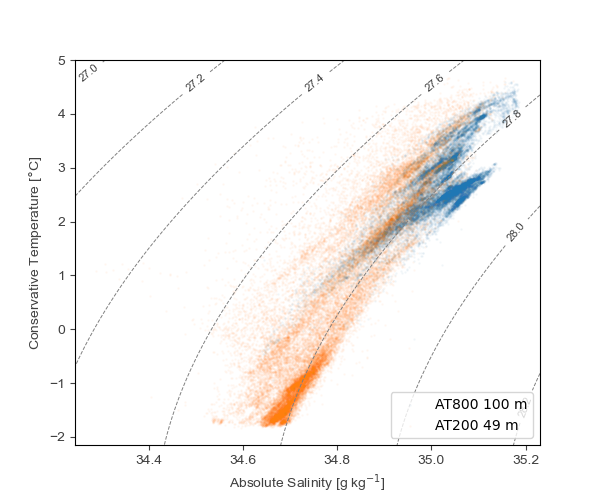

In [23]:
fig, ax = tsplot.ts_axes(datasets=[ds_at800_100m, ds_at200_50m])

scatter_kws = {'alpha': 0.03, 's': 1}
ax.scatter(ds_at800_100m.SA, ds_at800_100m.CT, label='AT800 100 m', **scatter_kws)
ax.scatter(ds_at200_50m.SA,  ds_at200_50m.CT,  label='AT200 49 m',  **scatter_kws)
ax.legend()

> ✏️ **Review note** — the cells from here to the end are exploratory working notes from investigating how close the AT200 water gets to freezing, not finished notebook content. They repeat imports and recompute the same quantities several ways. Decide what to keep: the distance-to-freezing time series and the histogram are genuinely interesting and would make a good closing section, but they need consolidating into one clean block with prose around them.

___

**Next:** [8. Sound speed →](./08_initial_analysis_sound_speed.ipynb)